In [16]:
import numpy as np
from scipy.stats import gamma
import matplotlib.pyplot as plt

# Importance Sampling

Importance sampling is a method of calculating properties of a known, but hard to sample distribution.

The idea is to take samples from a well known distribution and turn them into an estimate.



$$
\begin{aligned}
E_V(x) &\approx \sum^n_{i=1} x_i f_V(x_i)\\
&\approx \sum^n_{i=1} x_i f_V(x_i) \frac{f_U(x_i)}{f_U(x_i)}\\
&\approx \sum^n_{i=1} (x_i \frac{f_V(x_i)}{f_U(x_i)}) f_U(x_i)\\
&\approx E_U(x \frac{f_V(x)}{f_U(x)})\\
\end{aligned}
$$

$$
\begin{aligned}
Var_V(x) &= E_V(x^2) - E_V(x)^2\\
Var_V(x) &\approx (\sum^n_{i=1} x_i^2 f_V(x)) - (\sum^n_{j=1} x_j f_V(x))^2\\
&\approx (\sum^n_{i=1} x_i^2 f_V(x)\frac{f_U(x_i)}{f_U(x_i)}) - (\sum^n_{j=1} x_j f_V(x)\frac{f_U(x_j)}{f_U(x_j)})^2\\
&\approx (\sum^n_{i=1} x_i^2 \frac{f_V(x_i)}{f_U(x_i)}f_U(x_i)) - (\sum^n_{j=1} x_j \frac{f_V(x_j)}{f_U(x_j)}f_U(x_j))^2\\
&\approx E_U(x^2 \frac{f_V(x)}{f_U(x)}) - E_U(x \frac{f_V(x)}{f_U(x)})^2\\
\end{aligned}
$$

## Using the Uniform Distribution to sample from Standard Normal

The normal distribution does not have a nice closed form cdf, this it makes it hard to directly sample using the inverse CDF method.

Even though there are established methods to do so, this is to portray an example

In [17]:
mu, sigma = 12, 1

x_min = max([0, mu-4*sigma]) # needs to be non zero
x_max = mu+4*sigma

uniform_pdf = lambda x: 1/(x_max-x_min) * np.ones(x.shape)
arcsin_pdf = lambda x: 1/(np.pi*np.sqrt(x*(1-x)))
arcsin_inv_cdf = lambda x: np.sin(np.pi*x/2)**2 # used to generate samples
exp_pdf = lambda x: np.exp(-x) # exp(1)
exp_inv_cdf = lambda x: -np.log(1-x) # used to generate samples
standard_normal_pdf = lambda x: np.exp(-0.5*((x-mu)/sigma)**2)/np.sqrt(2*np.pi*sigma*sigma)



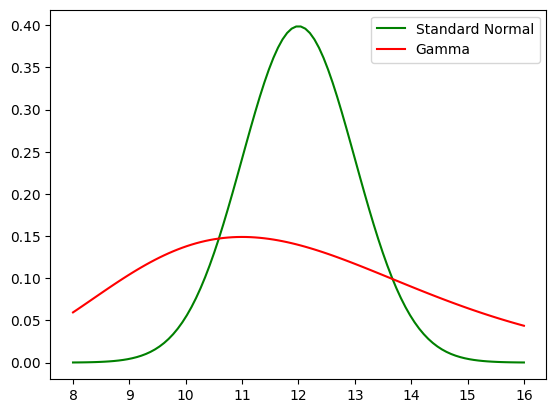

In [18]:
x = np.linspace(x_min,x_max, num=100)

plt.plot(x, standard_normal_pdf(x), c="green", label="Standard Normal")
plt.plot(x, gamma.pdf(x, 8,4), c="red", label="Gamma")

plt.legend()
plt.show()

In [19]:
num_samples = 10_000_000
x_sample = np.random.uniform(x_min, x_max, size=num_samples)

normal_unif_weight = standard_normal_pdf(x_sample)/uniform_pdf(x_sample)
importance_sample_mean_unif_est = (normal_unif_weight*x_sample).mean() # note that this is close to the true mean
importance_sample_var_unif_est = (normal_unif_weight*x_sample*x_sample).mean() - importance_sample_mean_unif_est**2

arcsin_sample = arcsin_inv_cdf(np.random.uniform(0, 1, size=num_samples))
normal_arcsin_weight = standard_normal_pdf(arcsin_sample)/arcsin_pdf(arcsin_sample)
importance_sample_mean_arcsin_est = (normal_arcsin_weight*arcsin_sample).mean() # note that this is close to the true mean
importance_sample_var_arcsin_est = (normal_arcsin_weight*arcsin_sample*arcsin_sample).mean() - importance_sample_mean_arcsin_est**2

exp_sample = exp_inv_cdf(np.random.uniform(0, 1, size=num_samples))
normal_exp_weight = standard_normal_pdf(exp_sample)/exp_pdf(exp_sample)
importance_sample_mean_exp_est = (normal_exp_weight*exp_sample).mean() # note that this is close to the true mean
importance_sample_var_exp_est = (normal_exp_weight*exp_sample*exp_sample).mean() - importance_sample_mean_exp_est**2

gamma_sample = gamma.rvs(a=mu, size=num_samples)
normal_gamma_weight = standard_normal_pdf(gamma_sample)/gamma.pdf(gamma_sample, a=mu)
importance_sample_mean_gamma_est = (normal_gamma_weight*gamma_sample).mean() # note that this is close to the true mean
importance_sample_var_gamma_est = (normal_gamma_weight*gamma_sample*gamma_sample).mean() - importance_sample_mean_gamma_est**2

/tmp/ipykernel_1419/1929636017.py:7: RuntimeWarning: divide by zero encountered in divide
  arcsin_pdf = lambda x: 1/(np.pi*np.sqrt(x*(1-x)))


In [20]:
normal_exp_weight

array([5.93772164e-30, 1.19656388e-30, 3.41713258e-31, ...,
       5.74156608e-32, 4.43258166e-32, 1.11327346e-26], shape=(10000000,))

In [21]:

print("Estimated Mean and Variance using uniform:",importance_sample_mean_unif_est, importance_sample_var_unif_est)
print("Estimated Mean and Variance using arcsin:",importance_sample_mean_arcsin_est, importance_sample_var_arcsin_est)
print("Estimated Mean and Variance using exp:",importance_sample_mean_exp_est, importance_sample_var_exp_est)
print("Estimated Mean and Variance using gamma:",importance_sample_mean_gamma_est, importance_sample_var_gamma_est)
print("True Mean and Variance:", mu, sigma*sigma)

Estimated Mean and Variance using uniform: 12.000794355728095 0.9952517102847764
Estimated Mean and Variance using arcsin: 1.7398787243985296e-28 1.5993353907768762e-28
Estimated Mean and Variance using exp: 11.961323251352646 0.9697115691116096
Estimated Mean and Variance using gamma: 11.997126943260042 1.024167740500701
True Mean and Variance: 12 1


The more differently shaped the distribution, the more likely the estimate will be poor.

